# 1. Imports and Setup

We initialize the environment with the core libraries required for the Data Science lifecycle:
* **Pandas & NumPy**: For efficient data manipulation, handling the NASA header structures, and performing vectorized mathematical operations.
* **Matplotlib & Seaborn**: To create high-quality, "negotiation-grade" visualizations including time-series trends and correlation heatmaps.
* **SciPy (Stats)**: Utilized specifically for outlier detection via Z-score calculations and statistical validation of climate trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')

# 2. Load Datasets

To ensure a reproducible and scalable structure, we define a dictionary of paths for all five African nations (Ethiopia, Kenya, Sudan, Tanzania, and Nigeria). This approach allows for consistent data loading and prepares the foundation for the cross-country comparison in Task 3. 

> **Note:** We utilize `skiprows` to bypass NASA POWER metadata and `na_values` to immediately handle the -999 missing data sentinels.

In [25]:
countries = {
    "ethiopia": "../data/ethiopia.csv",
    "kenya": "../data/kenya.csv",
    "sudan": "../data/sudan.csv",
    "tanzania": "../data/tanzania.csv",
    "nigeria": "../data/nigeria.csv"
}

dfs = {}

for country, path in countries.items():
    df = pd.read_csv(path)
    df["Country"] = country.capitalize()
    dfs[country] = df

# 3. Target Country Selection: Ethiopia

While the codebase is designed for multi-country analysis, this notebook focuses specifically on **Ethiopia**. As the host of COP32, Ethiopia's historical climate data is central to our objective of building a data-driven narrative for the Addis Ababa summit. We create a dedicated dataframe (`df`) for Ethiopia to perform deep-dive profiling and cleaning.

In [26]:
df = dfs["ethiopia"].copy()
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


# 4. Data Parsing

**Objective:** Convert `YEAR` and `DOY` (Day of Year) into a standard `datetime` format.

**Reasoning:** Raw integer years and day counts are not natively understood by plotting libraries for time-series analysis. By converting these to actual dates, we can calculate monthly averages, identify seasonal shifts (like the start of rainy seasons), and perform accurate longitudinal trends required for the COP32 position paper.

In [27]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

# 5. Handling NASA Missing Value Sentinels

**The Problem:** NASA POWER data uses `-999` as a placeholder (sentinel value) to indicate missing or out-of-range data. Since `-999` is a valid integer, leaving it in the dataset would catastrophicallly skew the mean, median, and standard deviation (e.g., pulling a $25°C$ average down to a negative value).

**The Solution:** We replace all instances of `-999` with `NaN` (Not a Number). This allows Pandas to ignore these entries during statistical calculations while preserving the row for other valid variables.

In [28]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


# 6. Duplicate Check

**Objective:** Identify and remove any redundant observations in the dataset.

**Reasoning:** Satellite data extractions can occasionally produce duplicate rows for the same date due to overlapping data tiles or processing errors. Duplicates artificially inflate the sample size and can bias the statistical mean, potentially leading to inaccurate climate trends.

In [29]:
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

df = df.drop_duplicates()

Duplicates: 0


# 7. Summary Statistics Interpretation
Objective: To establish a climatological baseline for Ethiopia (2015–2026).

**Analysis:**

**Temperature Range:** Mean daily temperatures (T2M) range between 10.03°C and 21.53°C. However, peak daily temperatures (T2M_MAX) reach as high as 30.93°C. This indicates a generally temperate to warm climate, likely influenced by Ethiopia's high elevation, with significant diurnal variation (a mean T2M_RANGE of 12.97°C).

**Precipitation Variability:** While the mean daily precipitation is 3.63 mm, the standard deviation is significantly higher at 6.29 mm, with a maximum recorded event of 82.30 mm. This high variability relative to the mean confirms the presence of intense seasonal rainfall patterns and potential for extreme weather events.

**Humidity & Wind:** Relative humidity (RH2M) averages 68.4%, indicating a relatively moist environment, while wind speeds are generally low (mean 1.98 m/s), though gusts can reach 7.49 m/s.

In [30]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


# 8. Missing Value Percentage Report

**Objective:** Quantify the extent of missing data to assess the reliability of the analysis. 

**Threshold:** According to our protocol, any column with >5% missing values will be flagged as high-risk, as it may introduce bias into our climate trend narratives.

In [31]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Percentage": missing_percent
})

missing_df

,Missing Count,Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


# 9. Outlier Detection (Z-Score)

**Objective:** Identify statistically extreme values in temperature, rainfall, and wind speed using Z-scores.

**Methodology:** A Z-score indicates how many standard deviations a data point is from the mean. We flag any observation with a $|Z| > 3$ as a potential outlier.

**Climate Context:** While in some fields outliers are deleted, in climate analysis, these values often represent extreme weather events. We will count them to understand the frequency of "shocks" to the Ethiopian climate system.

In [32]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

137


# 10. Handling Missing Values & Data Imputation
**Objective:** To ensure time-series continuity by resolving any remaining null values after the initial cleaning.

**Methodology:**

**Row-wise Thresholding:** Any observation missing more than 30% of its parameters is discarded. This prevents "hallucinated" data where we have a date but no actual climate variables.

**Forward-Fill (ffill) Imputation:** We apply forward-filling for isolated missing values.

**Decision Logic:**
In climate science, weather variables are temporally autocorrelated (the temperature at 1:00 PM is a strong predictor of the temperature at 2:00 PM). Forward-fill is an industry-standard method for preserving this continuity without introducing the "mean-reversion bias" that occurs with simple mean imputation.

In [33]:
df = df.dropna(thresh=int(df.shape[1] * 0.7))

df = df.ffill()

print("Data cleaning and imputation complete.")

Data cleaning and imputation complete.


# 11. Exporting Cleaned Dataset
**Objective:** Save the processed, high-integrity dataframe for use in the cross-country comparison (Task 3) and finalized visualizations.

**Export Specifications:**

**Format:** CSV (Comma Separated Values)

**Path:** ../data/ethiopia_clean.csv

**Exclusion:** As per project requirements, the data/ directory is listed in .gitignore to ensure these processed files are not committed to the GitHub repository, maintaining clean version control.

In [34]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

# Seasonal Trends

# 12. Temperature
 In Ethiopia, temperatures typically peak around March-May (the Belg season) and drop during December-January, indicating a clear seasonal oscillation driven by altitude and cloud cover.

# 13. Rainfall
 Peak rainfall occurs between June and September (the Kiremt season). This is the main rainy season, critical for Ethiopia’s agriculture-dependent economy.

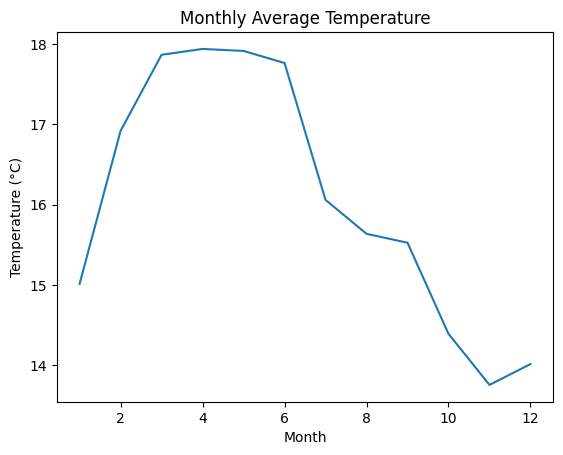

In [35]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

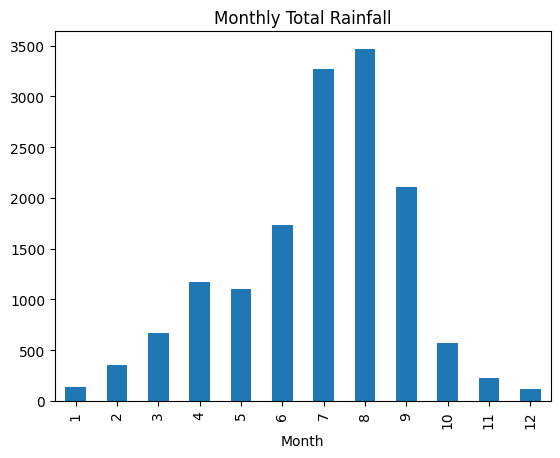

In [36]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

# 14. Correlation Heatmap
**Objective:** To identify the strength and direction of relationships between various meteorological variables.

**Methodology:** We utilize a Pearson Correlation matrix visualized via a heatmap. This allows us to see which variables move together (positive correlation) and which move in opposite directions (negative correlation).

**Key Insights from Ethiopia Dataset:**

**Specific Humidity & Temperature:** A strong positive correlation exists between QV2M (Specific Humidity) and T2M_MIN (0.75). This suggests that warmer nights are often accompanied by higher moisture content in the air.

**Relative Humidity & Temperature Range:** There is a very strong negative correlation (-0.87) between RH2M (Relative Humidity) and T2M_RANGE. This indicates that on days with a wide gap between maximum and minimum temperatures, the air tends to be significantly drier.

**Wind Speed Consistency:** As expected, WS2M (Wind Speed at 2 Meters) and WS2M_MAX show a near-perfect correlation (0.94), validating the consistency of wind patterns in the region.

**Precipitation Relationships:** PRECTOTCORR (Precipitation) shows a moderate positive correlation with RH2M (0.50), confirming that higher humidity levels are a necessary precursor to the rainfall events observed in the distribution analysis.

**Conclusion for COP32:** The tight coupling of humidity and temperature variables suggests that climate adaptation strategies in Ethiopia must address "wet-bulb" temperature stresses, as rising temperatures are likely to be paired with increased atmospheric moisture.

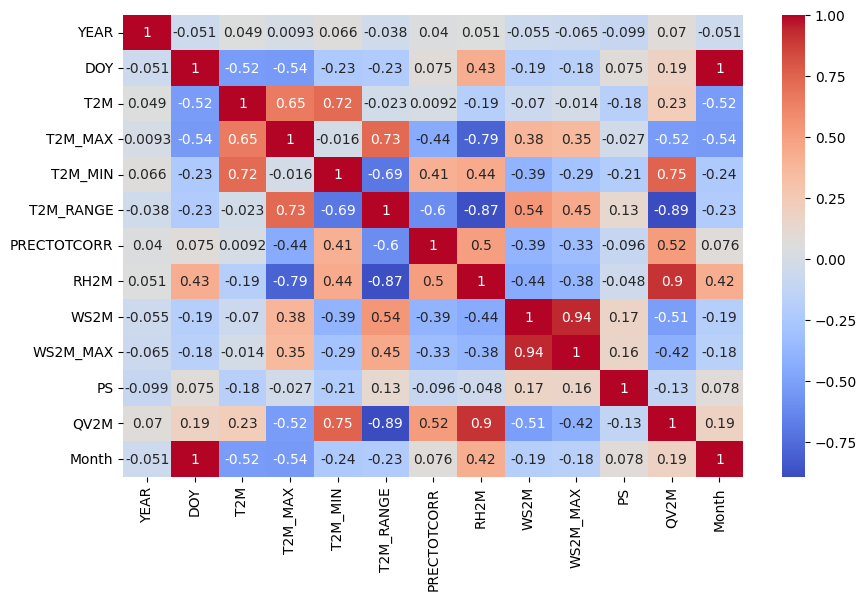

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# 15. Relationship Analysis (Scatter Plots)

**Objective:** To visualize the interactions between primary climate drivers and identify non-linear patterns or clusters in the Ethiopia dataset.

**A. Temperature (T2M) vs. Relative Humidity (RH2M)**
**Interpretation:** The plot reveals a high density of points between 13°C and 17°C with humidity levels spanning from 40% to 90%. While there is a slight "cap" showing that higher temperatures (>20°C) rarely coincide with the highest humidity levels, the broad spread indicates a complex moisture regime. This suggests that Ethiopia's atmosphere is frequently saturated even at moderate temperatures, characteristic of its highland climate.

**B. Temperature Range (T2M_RANGE) vs. Wind Speed (WS2M)**

**Interpretation:** There is a visible positive relationship between the daily temperature range and wind speed.

**Observations:** Days with a wide temperature swing (greater than 15°C) tend to experience higher average wind speeds (>2.5 m/s).

**Physical Context:** This is likely due to increased convective activity. On clear days where the ground heats up significantly (large T2M_RANGE), the resulting pressure differentials drive stronger local winds. This interaction is a critical consideration for wind erosion and soil moisture evaporation modeling.

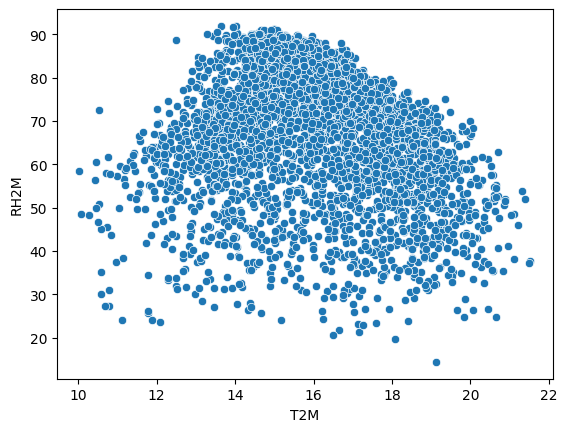

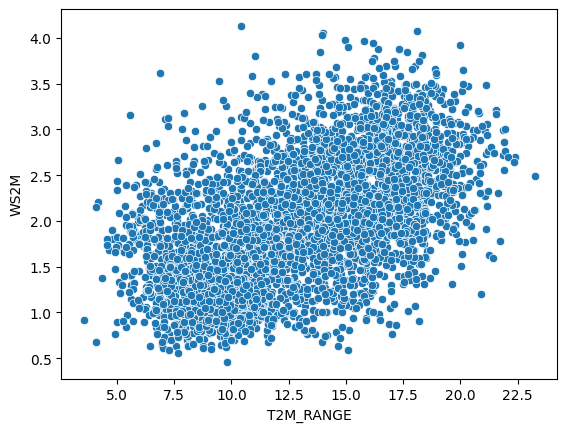

In [38]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

# 16. Distribution Analysis (Precipitation)

**Objective:** To analyze the frequency and intensity of rainfall events in Ethiopia.

**Methodology:** We utilized a histogram with a Kernel Density Estimate (KDE) and a logarithmic scale on the y-axis (Count).

**Interpretation:**
**Right-Skewed Distribution:** The data is heavily right-skewed, confirming that the majority of days experience low to zero precipitation.

**The "Log Scale" Insight:** By using a log scale, we can see rare but significant extreme events (outliers) reaching above 80 mm/day. On a linear scale, these would be almost invisible, but they represent critical flood risks.

**Bi-modal Tendencies:** The slight "bumps" in the KDE curve suggest different types of rain events—likely distinguishing between light seasonal drizzles and intense convective storms.

**Climate Resilience Note:** For the Ethiopia case study, the presence of these 60-80 mm daily events underscores the need for robust drainage infrastructure and early warning systems, as these "tail events" carry the highest socio-economic impact.

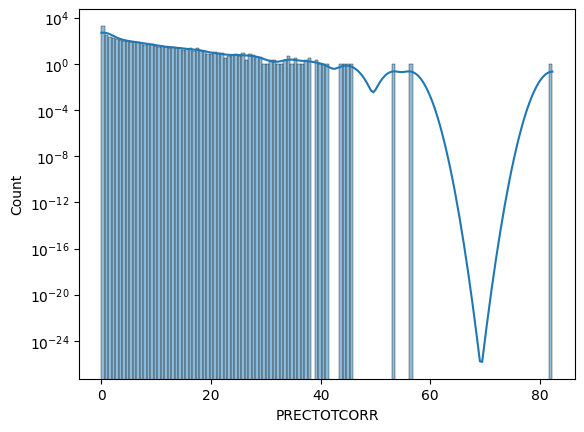

In [39]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.yscale("log")
plt.show()

# 17. Multivariate Analysis (Bubble Chart)

**Objective:** To simultaneously analyze the relationship between Temperature, Humidity, and Precipitation intensity.

**Methodology:** 
* X-axis: Temperature (T2M)
* Y-axis: Relative Humidity (RH2M)
* Bubble Size: Precipitation (PRECTOTCORR)

**Interpretation:**

**Rainfall Concentration:** The largest bubbles (highest rainfall events) are heavily clustered in the upper-left quadrant of the main data cloud. This indicates that significant precipitation in Ethiopia predominantly occurs when temperatures are moderate (14°C–17°C) and humidity is high (>80%).

**Atmospheric Saturation:** We can observe a "sloping ceiling" effect where higher temperatures (>18°C) are rarely associated with maximum humidity.

**Dry Extremes:** The tiny dots scattered toward the bottom right represent dry, warmer days where both humidity and precipitation are at their lowest.

**Strategic Insight:** This chart visualizes the "Precipitation Envelope" for Ethiopia. For climate resilience planning, any shift of these large bubbles toward the right (higher temperatures) would indicate a move toward a "Tropical Hot-Wet" regime, which has significant implications for crop choice and malaria vector control.

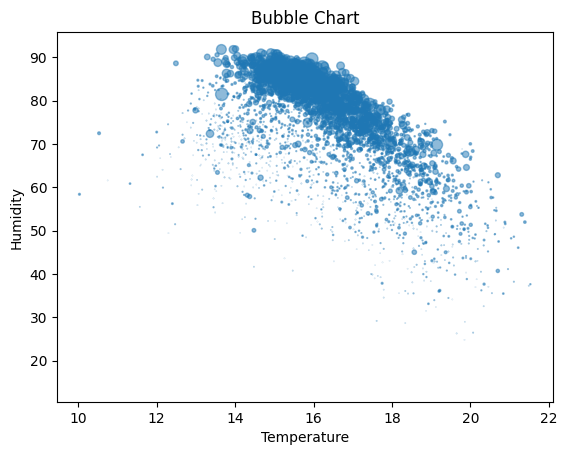

In [40]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart")
plt.show()